
# Linear Regression on House Price Dataset

## Objective
To understand and implement **Linear Regression** for predicting house prices.

---

## What we will learn
- What is regression
- How features affect price
- How to train a model
- How to evaluate using R²


In [1]:

# STEP 1: Import Libraries

# pandas -> for data handling
import pandas as pd

# matplotlib -> for plotting graphs
import matplotlib.pyplot as plt

# sklearn -> for machine learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score


In [2]:

# STEP 2: Load Dataset

# Read CSV file into dataframe
df = pd.read_csv("house_price_dataset_v2.csv")

# Display first 5 rows
df.head()


,Rooms,Distance,Bathroom,Car,Landsize,Price
0,2,10,1,1,200,45
1,3,8,2,2,300,60
2,4,6,2,2,400,75
3,3,7,2,2,350,65
4,5,5,3,3,500,90


In [3]:

# STEP 3: Understand Dataset

# Shape tells number of rows and columns
print("Shape:", df.shape)

# Column names
print("Columns:", df.columns.tolist())

# Statistical summary
df.describe()


Shape: (10, 6)
Columns: ['Rooms', 'Distance', 'Bathroom', 'Car', 'Landsize', 'Price']


,Rooms,Distance,Bathroom,Car,Landsize,Price
count,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
mean,3.500000,7.200000,1.900000,1.900000,367.000000,70.000000
std,1.080123,2.529822,0.737865,0.737865,117.288817,17.480147
min,2.000000,4.000000,1.000000,1.000000,200.000000,45.000000
25%,3.000000,5.250000,1.250000,1.250000,285.000000,56.250000
50%,3.500000,6.500000,2.000000,2.000000,375.000000,70.000000
75%,4.000000,8.750000,2.000000,2.000000,442.500000,83.750000
max,5.000000,12.000000,3.000000,3.000000,550.000000,95.000000


In [4]:

# STEP 4: Define Features and Target

# X = input features (independent variables)
# y = output (dependent variable)

X = df.drop("Price", axis=1)   # remove target column
y = df["Price"]               # target variable

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())


Features:
   Rooms  Distance  Bathroom  Car  Landsize
0      2        10         1    1       200
1      3         8         2    2       300
2      4         6         2    2       400
3      3         7         2    2       350
4      5         5         3    3       500

Target:
0    45
1    60
2    75
3    65
4    90
Name: Price, dtype: int64


In [5]:

# STEP 5: Split Dataset

# 80% training, 20% testing
# random_state ensures same split every time

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)


Training size: (8, 5)
Testing size: (2, 5)


In [6]:

# STEP 6: Train Model

# Create Linear Regression model
model = LinearRegression()

# Fit model (learn from training data)
model.fit(X_train, y_train)

print("Model trained successfully")


Model trained successfully


In [7]:

# STEP 7: Make Predictions

# Predict house prices for test data
y_pred = model.predict(X_test)

print("Predicted values:", y_pred)
print("Actual values:", y_test.values)


Predicted values: [99.64285714 57.5       ]
Actual values: [95 60]


In [8]:

# STEP 8: Evaluate Model

# R² score measures how well model explains data
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)


R² Score: 0.9546022490628893


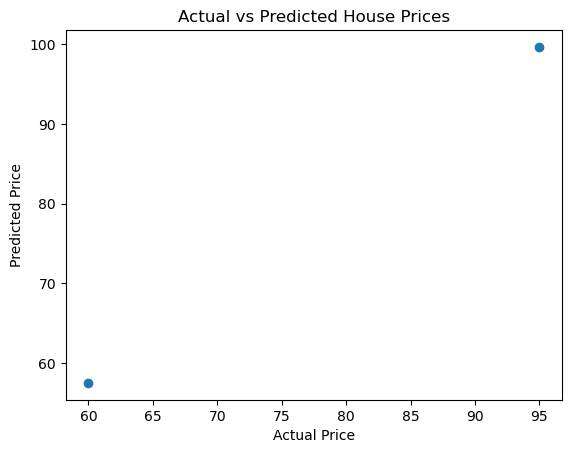

In [9]:

# STEP 9: Visualization

# Compare actual vs predicted values

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.show()


In [10]:

# STEP 10: Understand Coefficients

# Coefficients show importance of each feature

coeff_df = pd.DataFrame(model.coef_, X.columns, columns=["Coefficient"])

print(coeff_df)


          Coefficient
Rooms       -2.142857
Distance     1.071429
Bathroom    -1.428571
Car         -1.428571
Landsize     0.214286



## Final Conclusion

- Model learns relationship between features and price
- R² shows model performance
- More features → better prediction
- Linear Regression is useful for prediction problems

---

## One Line Summary
Linear Regression predicts house price based on features like rooms, distance, and land size.


## Practical-7 Submission Section (Minimum Required)

This section trains:
- Simple Linear Regression (best single predictor)
- Multiple Linear Regression (all selected predictors)
- R-squared comparison

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

sns.set(style="whitegrid")

df = pd.read_csv("house_price_dataset_v2.csv")
print("Dataset shape:", df.shape)

target = "Price"
features = [c for c in ["Rooms", "Distance", "Bathroom", "Car", "Landsize"] if c in df.columns]
if target not in df.columns or len(features) < 2:
    raise ValueError("Expected columns not found for Practical-7 regression")

df = df[features + [target]].dropna().copy()

# Best single predictor by absolute correlation
best_feature = df[features].corrwith(df[target]).abs().sort_values(ascending=False).index[0]

X_simple = df[[best_feature]]
X_multi = df[features]
y = df[target]

Xs_train, Xs_test, ys_train, ys_test = train_test_split(X_simple, y, test_size=0.2, random_state=42)
Xm_train, Xm_test, ym_train, ym_test = train_test_split(X_multi, y, test_size=0.2, random_state=42)

simple_model = LinearRegression().fit(Xs_train, ys_train)
multi_model = LinearRegression().fit(Xm_train, ym_train)

r2_simple = r2_score(ys_test, simple_model.predict(Xs_test))
r2_multi = r2_score(ym_test, multi_model.predict(Xm_test))

comparison = pd.DataFrame({
    "Model": ["Simple Linear Regression", "Multiple Linear Regression"],
    "Features": [best_feature, ", ".join(features)],
    "R_squared": [r2_simple, r2_multi]
})
display(comparison)

plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x=best_feature, y=target, alpha=0.7)
plt.title(f"Best Predictor ({best_feature}) vs {target}")
plt.tight_layout()
plt.show()

print("\nConclusion (minimum):")
print("Compare R-squared values above to identify whether simple or multiple regression performs better.")